<a href="https://colab.research.google.com/github/paridhi-rangari/Paridhi/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - Phase 1
## Dataset: Body Performance Dataset
**Student Name:** Paridhi rangari


**Registration number** 23BDS0242  
**Course:** EDA

# 1. Loading the Dataset

In [30]:
import pandas as pd

df = pd.read_csv("bodyPerformance.csv")

# 2. Basic Statistical Analysis

In [31]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  int64  
 1   gender                   13392 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13392 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13392 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(9), int64(1), object(2)
memory usage: 1.2+ MB


In [33]:
df.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13392.000000,13393.000000,13392.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240258,78.796842,130.233938,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.257107,10.742033,14.714152,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


# 3. Handling Missing Data

In [34]:
df.isnull().sum()

,0
age,0
gender,1
height_cm,0
weight_kg,0
body fat_%,1
diastolic,0
systolic,1
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


In [35]:
# Fill missing value in gender with the most common value
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# Fill missing values in numerical columns with their mean
df['body fat_%'] = df['body fat_%'].fillna(df['body fat_%'].mean())
df['systolic'] = df['systolic'].fillna(df['systolic'].mean())

In [36]:
df.isnull().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


In [37]:
df.duplicated().sum()

np.int64(1)

In [38]:
df = df.drop_duplicates()

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

In [41]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

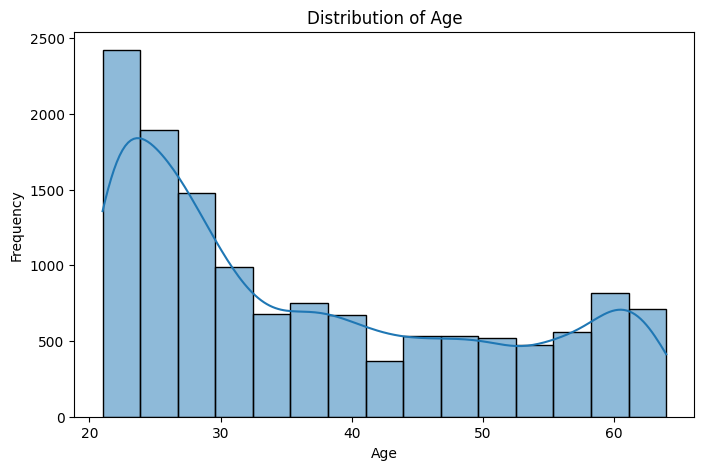

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=15, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

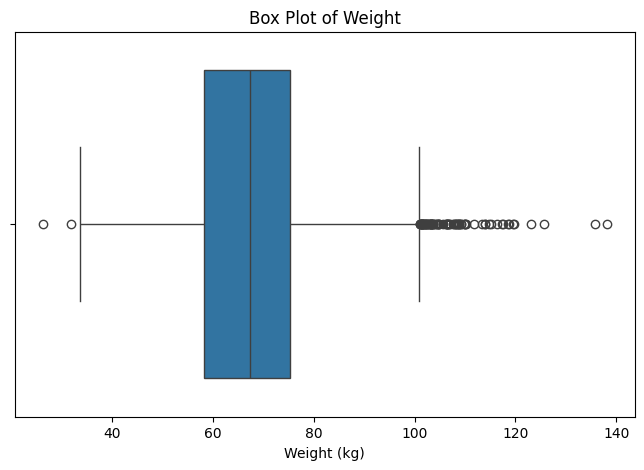

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['weight_kg'])

plt.title("Box Plot of Weight")
plt.xlabel("Weight (kg)")

plt.show()

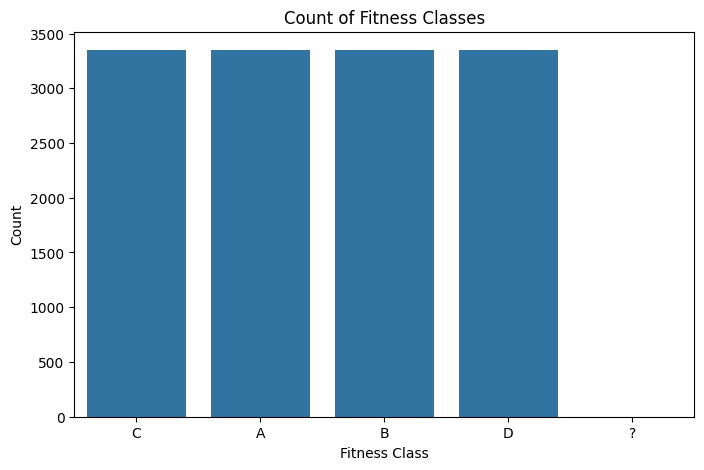

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='class', data=df)

plt.title("Count of Fitness Classes")
plt.xlabel("Fitness Class")
plt.ylabel("Count")

plt.show()

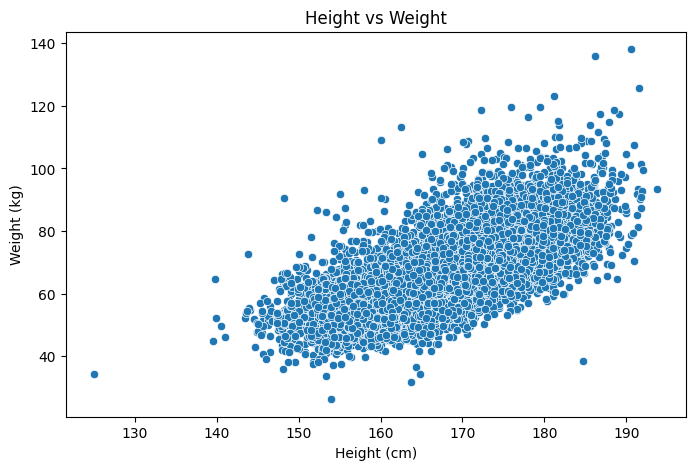

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='height_cm', y='weight_kg', data=df)

plt.title("Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")

plt.show()

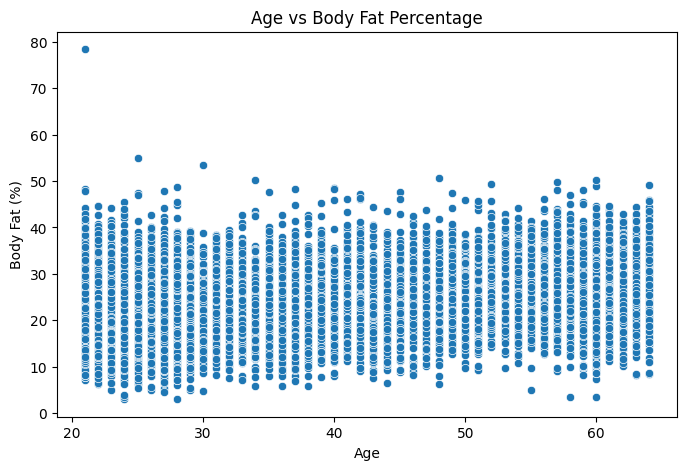

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='body fat_%', data=df)

plt.title("Age vs Body Fat Percentage")
plt.xlabel("Age")
plt.ylabel("Body Fat (%)")

plt.show()

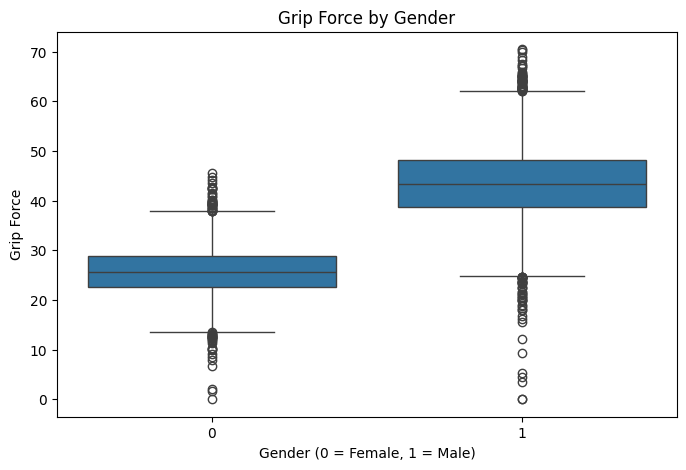

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='gripForce', data=df)

plt.title("Grip Force by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Grip Force")

plt.show()

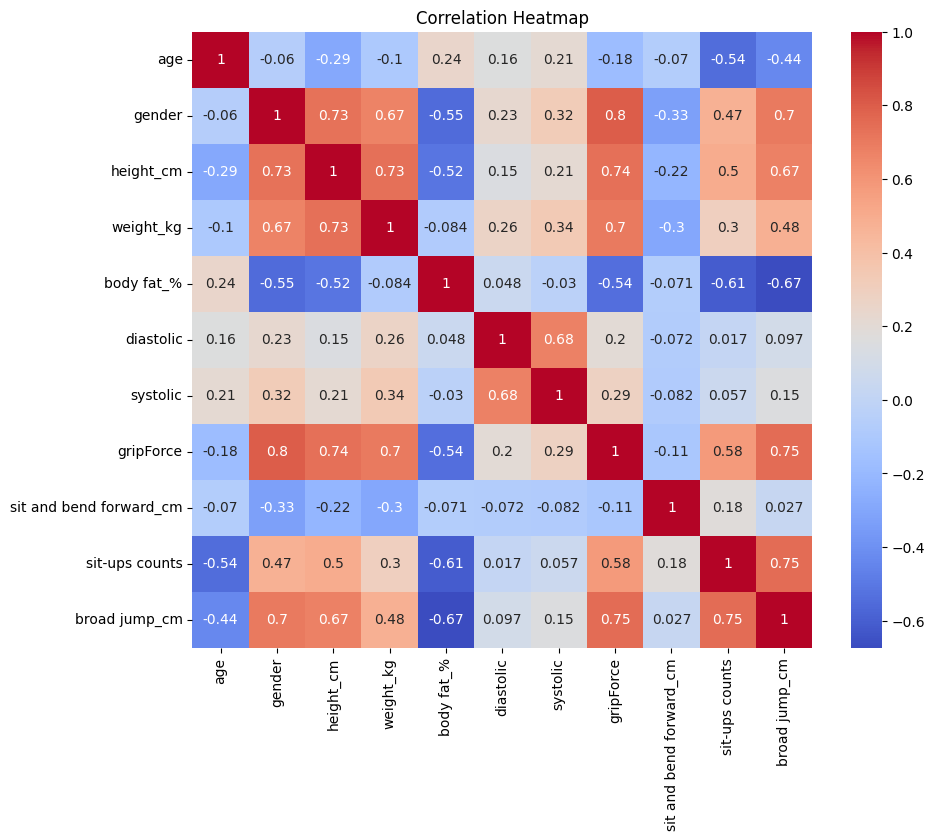

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

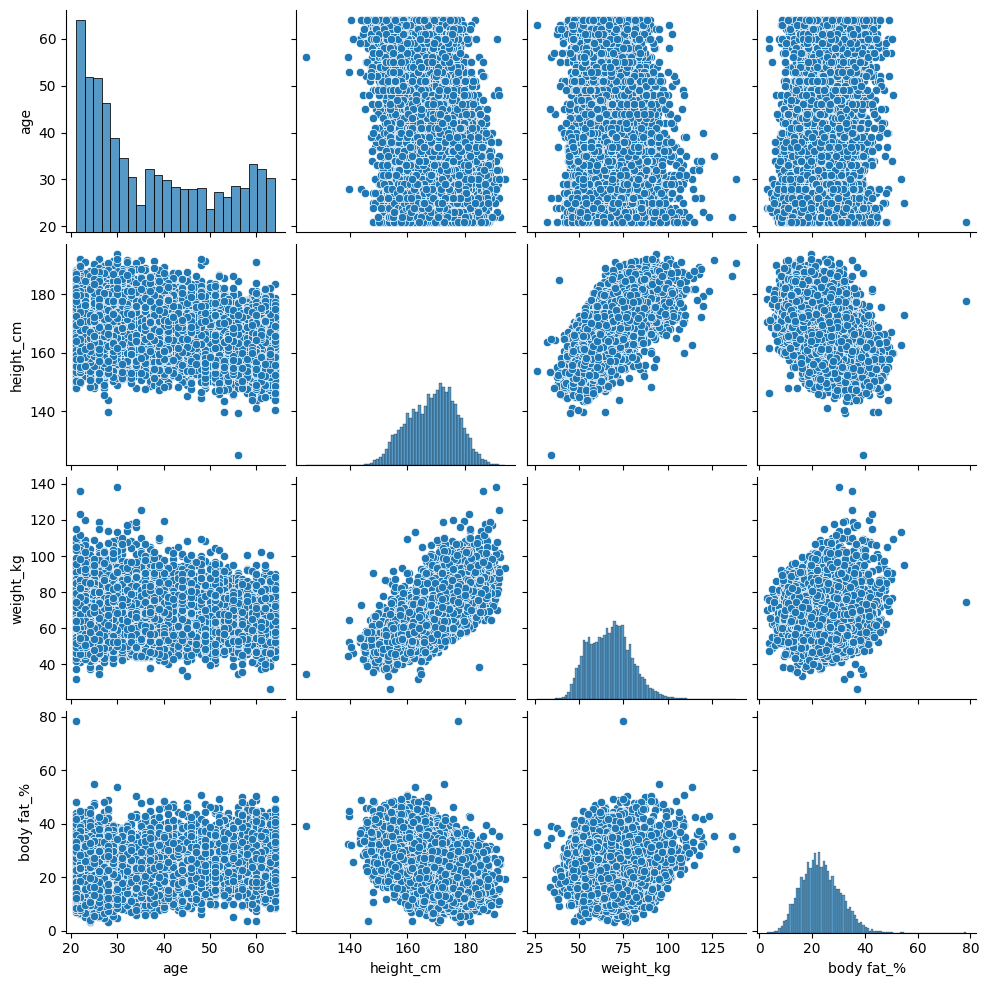

In [50]:
sns.pairplot(df[['age', 'height_cm', 'weight_kg', 'body fat_%']])

plt.show()

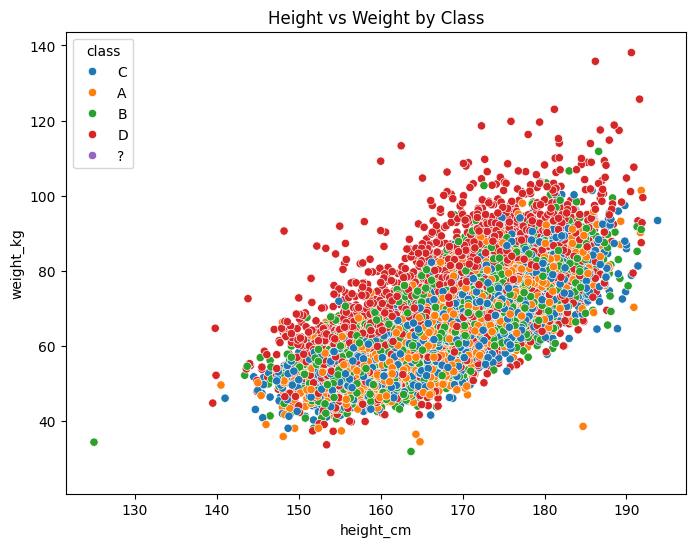

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='height_cm',
    y='weight_kg',
    hue='class',
    data=df
)

plt.title("Height vs Weight by Class")

plt.show()

# PHASE 2 – STATISTICAL ANALYSIS AND CLUSTERING

## 1. 1D Statistical Analysis

In [52]:
# 1D Statistical Analysis

numeric_columns = df.select_dtypes(include='number').columns

print("Descriptive Statistics:")
display(df[numeric_columns].describe())

Descriptive Statistics:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000
mean,36.775836,0.632243,168.560671,67.448686,23.239701,78.797499,130.237241,36.964569,15.208933,39.770385,190.131355
std,13.625886,0.482213,8.426305,11.949061,7.256821,10.742165,14.709185,10.624959,8.456904,14.276902,39.868988
min,21.000000,0.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,0.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,1.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,1.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,1.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


## 2. 2D Statistical Analysis

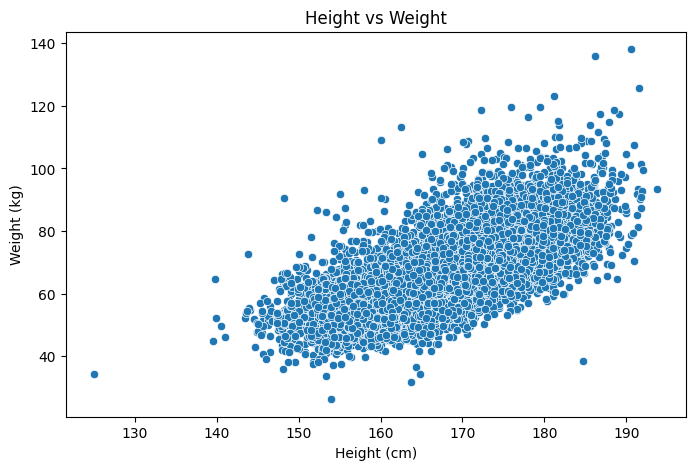

In [53]:
# 2D Statistical Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Height vs Weight
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='height_cm', y='weight_kg')
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

In [54]:
# Correlation between Height and Weight

correlation = df['height_cm'].corr(df['weight_kg'])

print("Correlation between Height and Weight:", correlation)

Correlation between Height and Weight: 0.7348683163322014


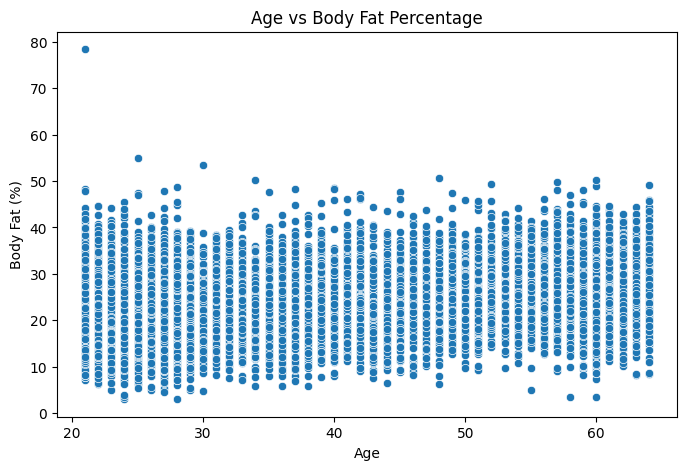

Correlation between Age and Body Fat Percentage: 0.24236073613249542


In [57]:
# 2D Analysis: Age vs Body Fat Percentage

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='body fat_%')

plt.title('Age vs Body Fat Percentage')
plt.xlabel('Age')
plt.ylabel('Body Fat (%)')
plt.show()

correlation_age_bodyfat = df['age'].corr(df['body fat_%'])

print("Correlation between Age and Body Fat Percentage:", correlation_age_bodyfat)

In [56]:
print(df.columns.tolist())

['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']


## 3. 3D Statistical Analysis


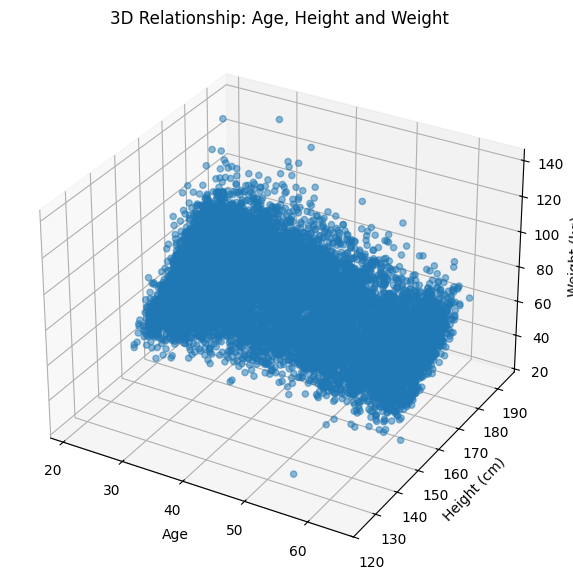

In [58]:
# 3D Statistical Analysis
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['age'],
    df['height_cm'],
    df['weight_kg'],
    alpha=0.5
)

ax.set_xlabel('Age')
ax.set_ylabel('Height (cm)')
ax.set_zlabel('Weight (kg)')
ax.set_title('3D Relationship: Age, Height and Weight')

plt.show()

## 4. K-Means Clustering

In [60]:
# K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
X = df[['age', 'height_cm', 'weight_kg']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Display cluster counts
print("Number of data points in each cluster:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Number of data points in each cluster:
KMeans_Cluster
0    6012
1    3578
2    3802
Name: count, dtype: int64


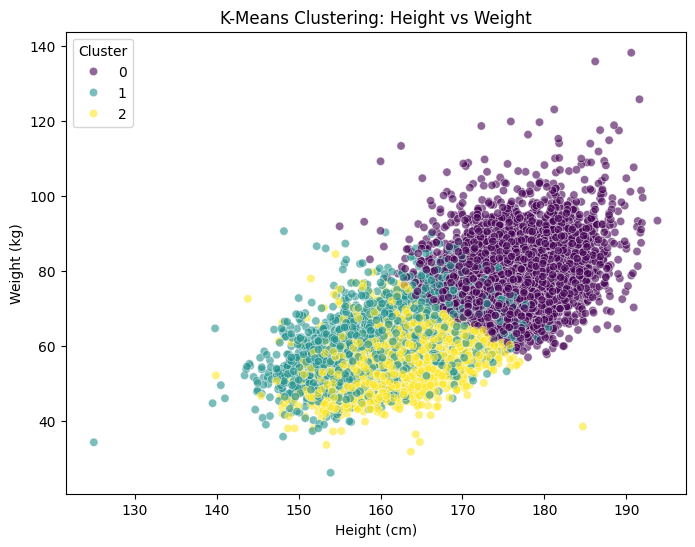

In [61]:
# K-Means Cluster Visualization

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='height_cm',
    y='weight_kg',
    hue='KMeans_Cluster',
    palette='viridis',
    alpha=0.6
)

plt.title('K-Means Clustering: Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend(title='Cluster')
plt.show()

## 5. Hierarchical Clustering

In [ ]:
# Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Use the same standardized data
linked = linkage(X_scaled, method='ward')

# Create dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.show()

In [65]:
# Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Use a sample of the dataset for hierarchical clustering
sample_size = 1000
X_sample = X_scaled[:sample_size]

# Create linkage matrix
linked = linkage(X_sample, method='ward')

# Create 3 hierarchical clusters
hierarchical_clusters = fcluster(
    linked,
    t=3,
    criterion='maxclust'
)

# Display cluster counts
print("Number of data points in each hierarchical cluster:")
print(pd.Series(hierarchical_clusters).value_counts().sort_index())

Number of data points in each hierarchical cluster:
1    472
2    199
3    329
Name: count, dtype: int64


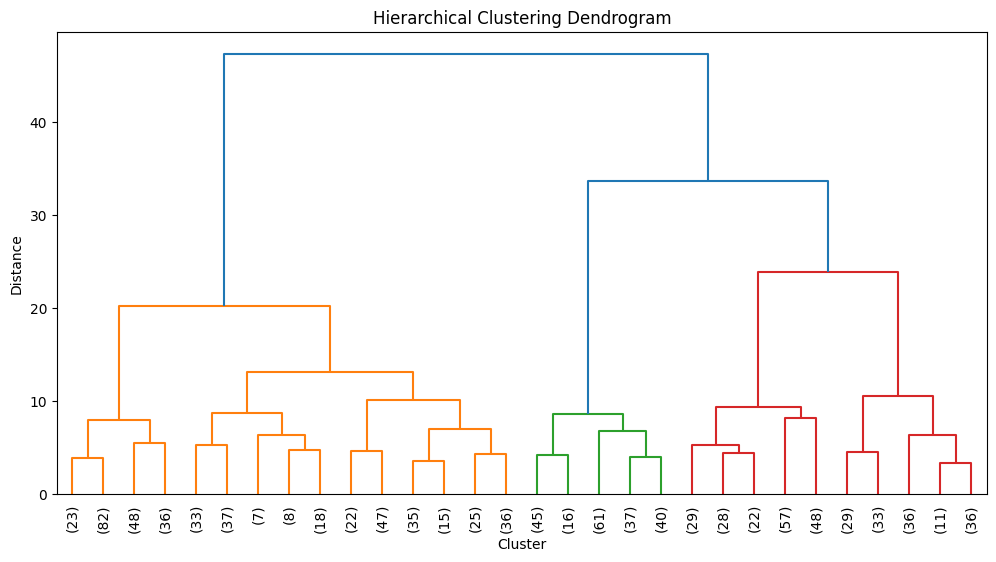

In [66]:
# Hierarchical Clustering Dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.show()